In [2]:
from os import chdir
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter

cwd = Path.cwd()
print(f"CWD: {cwd}")
if cwd.name == "code":
    chdir("..")
print(f"CWD: {Path.cwd()}")

CWD: /Users/haowen/Documents/Decentral RS/fed-learning-main/code
CWD: /Users/haowen/Documents/Decentral RS/fed-learning-main


In [3]:

# Load RMSE and time tables
df_rmse = pd.read_csv("ResultData/May23_2025/Random_2_out/rmse_table.csv")#ResultData/Random_5_out/
df_time = pd.read_csv("ResultData/May23_2025/Random_2_out/time_table.csv")
df_commute = pd.read_csv("ResultData/May23_2025/Random_2_out/commute_table.csv")

In [4]:
df_commute

,epoch,0,1,2,3,4,5,6,7,8,...,140,141,142,143,144,145,146,147,148,149
0,userprop,1885,1885,1885,1885,1885,1885,1885,1885,1885,...,1885.0,1885.0,1885.0,1885.0,1885.0,1885.0,1885.0,1885.0,1885.0,1885.0
1,urs,1885,1885,1885,1885,1885,1885,1885,1885,1885,...,1885.0,1885.0,1885.0,1885.0,1885.0,1885.0,1885.0,1885.0,1885.0,1885.0
2,rs,119807,119807,119807,119807,119807,119807,119807,119807,119807,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,oaat,119807,119807,119807,119807,119807,119807,119807,119807,119807,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,central,943,943,943,943,943,943,943,943,943,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,dmf,149750,149750,149750,149750,149750,149750,149750,149750,149750,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


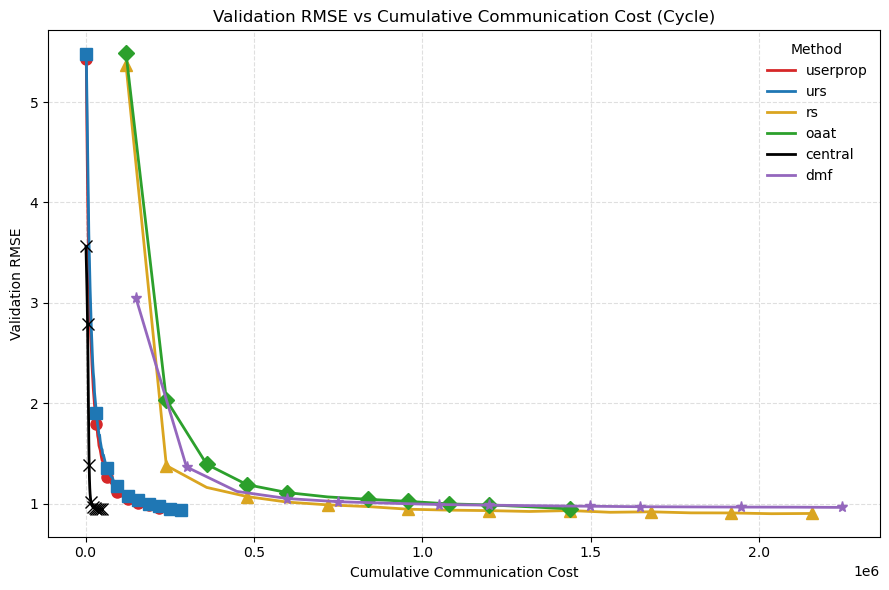

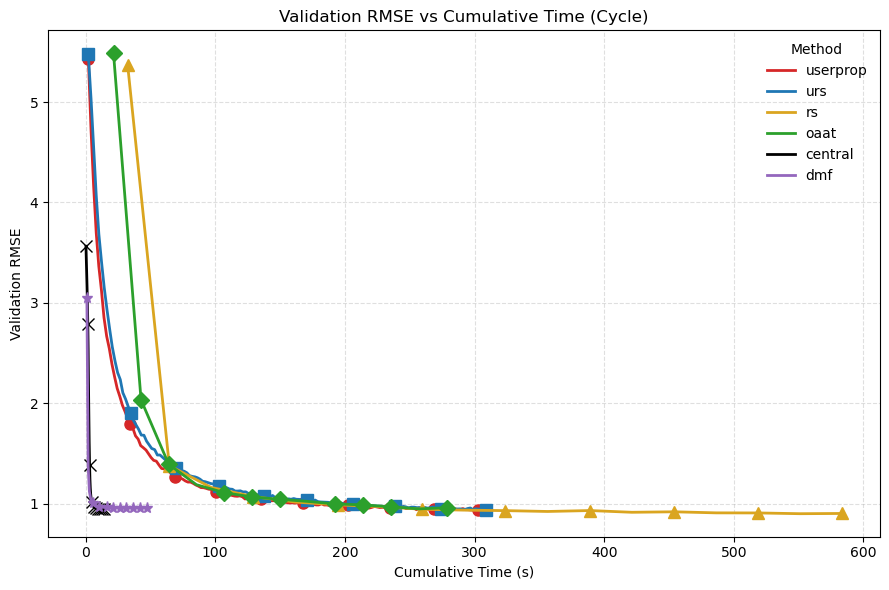

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter


# --- Method Setup ---
methods = df_rmse["epoch"].tolist()
colors = ["tab:red", "tab:blue", "goldenrod", "tab:green", "black", "tab:purple"]
markers = ["o", "s", "^", "D", "x", "*"]
style_map = {m: {"color": colors[i % len(colors)], "marker": markers[i % len(markers)]} for i, m in enumerate(methods)}

# --- Plot 1: RMSE vs Cumulative Communication Cost ---
plt.figure(figsize=(9, 6))
for method in methods[:3]:
    r = df_rmse[df_rmse["epoch"] == method].iloc[0, 1:].dropna().astype(float).values
    c = df_commute[df_commute["epoch"] == method].iloc[0, 1:].dropna().astype(float).values
    L = min(len(r), len(c))
    r, c = r[:L], c[:L]
    cc = np.cumsum(c)

    style = style_map[method]
    idx = np.linspace(0, L - 1, 10, dtype=int)
    plt.plot(cc, r, label=method, color=style["color"], linewidth=2)
    plt.plot(cc[idx], r[idx], linestyle='None', marker=style["marker"],
             color=style["color"], markersize=8)

method = methods[3]
r = df_rmse[df_rmse["epoch"] == method].iloc[0, 1:].dropna().astype(float).values
c = df_commute[df_commute["epoch"] == method].iloc[0, 1:].dropna().astype(float).values
L = 12#min(len(r), len(c))
r, c = r[:L], c[:L]
cc = np.cumsum(c)

style = style_map[method]
idx = np.linspace(0, L - 1, 10, dtype=int)
plt.plot(cc, r, label=method, color=style["color"], linewidth=2)
plt.plot(cc[idx], r[idx], linestyle='None', marker=style["marker"],
         color=style["color"], markersize=8)

for method in methods[4:5]:
    r = df_rmse[df_rmse["epoch"] == method].iloc[0, 1:].dropna().astype(float).values
    c = df_commute[df_commute["epoch"] == method].iloc[0, 1:].dropna().astype(float).values
    L = min(len(r), len(c))
    r, c = r[:L], c[:L]
    cc = np.cumsum(c)

    style = style_map[method]
    idx = np.linspace(0, L - 1, 10, dtype=int)
    plt.plot(cc, r, label=method, color=style["color"], linewidth=2)
    plt.plot(cc[idx], r[idx], linestyle='None', marker=style["marker"],
             color=style["color"], markersize=8)

method = methods[5]
r = df_rmse[df_rmse["epoch"] == method].iloc[0, 1:].dropna().astype(float).values
c = df_commute[df_commute["epoch"] == method].iloc[0, 1:].dropna().astype(float).values
L = 15#min(len(r), len(c))
r, c = r[:L], c[:L]
cc = np.cumsum(c)

style = style_map[method]
idx = np.linspace(0, L - 1, 10, dtype=int)
plt.plot(cc, r, label=method, color=style["color"], linewidth=2)
plt.plot(cc[idx], r[idx], linestyle='None', marker=style["marker"],
         color=style["color"], markersize=8)

plt.xlabel("Cumulative Communication Cost")
plt.ylabel("Validation RMSE")
plt.title("Validation RMSE vs Cumulative Communication Cost (Cycle)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="Method", frameon=False)
plt.tight_layout()
plt.savefig("rmse_vs_comm_cost_latest_final.png", dpi=300)
plt.show()

# --- Plot 2: RMSE vs Cumulative Time ---
plt.figure(figsize=(9, 6))
for method in methods[:6]:
    r = df_rmse[df_rmse["epoch"] == method].iloc[0, 1:].dropna().astype(float).values
    t = df_time[df_time["epoch"] == method].iloc[0, 1:].dropna().astype(float).values
    L = min(len(r), len(t))
    r, t = r[:L], t[:L]
    ct = np.cumsum(t)

    style = style_map[method]
    idx = np.linspace(0, L - 1, 10, dtype=int)
    plt.plot(ct, r, label=method, color=style["color"], linewidth=2)
    plt.plot(ct[idx], r[idx], linestyle='None', marker=style["marker"],
             color=style["color"], markersize=8)



plt.xlabel("Cumulative Time (s)")
plt.ylabel("Validation RMSE")
plt.title("Validation RMSE vs Cumulative Time (Cycle)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="Method", frameon=False)
plt.tight_layout()
plt.savefig("rmse_vs_time_latest_final.png", dpi=300)
plt.show()